<a href="https://colab.research.google.com/github/SiyumiJayawardhane/freshsense-imagemodel/blob/sithmi/Food_Spoilage_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for model selection, preprocessing, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# For handling imbalanced datasets (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE

# For saving and loading models
import joblib

## 1. Setup and Data Loading

In [2]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Define the file path to the dataset
file_path = '/content/drive/MyDrive/TemperatureDataset.csv'
# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Print basic information about the loaded dataset
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
print("First 5 rows of the dataset:")
# Rename columns for better readability and consistency
df.columns = ['Fruit', 'Temp', 'Humidity', 'MQ135', 'MQ3', 'Time']
# Display the first few rows of the DataFrame with new column names
print(df.head())

Mounted at /content/drive
Dataset loaded with 4558 rows and 6 columns.
First 5 rows of the dataset:
                                              Fruit  Temp  Humidity  MQ135  \
0  spoiled banana, spoiled cucumber, spoiled tomato  16.2      66.6      0   
1  spoiled banana, spoiled cucumber, spoiled tomato  16.2      67.8      0   
2  spoiled banana, spoiled cucumber, spoiled tomato  16.2      68.2      0   
3  spoiled banana, spoiled cucumber, spoiled tomato  16.3      67.3      0   
4  spoiled banana, spoiled cucumber, spoiled tomato  16.3      67.5      0   

    MQ3                 Time  
0  1188    4/6/2026 13:26:30  
1  1217  2026-04-06 13:28:44  
2  1157  2026-04-06 13:30:01  
3  1309  2026-04-06 13:45:01  
4  1337  2026-04-06 13:51:58  


In [3]:
# Display the initial dimensions (rows, columns) of the DataFrame
print("Initial shape:", df.shape)

Initial shape: (4558, 6)


## 2. Data Preprocessing and Feature Engineering

In [4]:
# Define a function to extract the main fruit type from the 'Fruit' column
def extract_fruit(text):
    # Convert text to lowercase for case-insensitive matching
    text = str(text).lower()
    # Check for specific fruit keywords
    if "banana" in text:
        return "banana"
    elif "cucumber" in text:
        return "cucumber"
    elif "tomato" in text:
        return "tomato"
    else:
        return "other" # Categorize as 'other' if no specific fruit is found

# Apply the function to the 'Fruit' column to standardize fruit names
df['Fruit'] = df['Fruit'].apply(extract_fruit)

In [5]:
# Define thresholds for MQ3 sensor readings to determine spoilage status
mq3_low = 800  # Threshold: below 800 indicates 'fresh'
mq3_high = 1200 # Threshold: 800-1199 indicates 'at-risk', 1200+ indicates 'spoiled'

# Define a function to assign a spoilage status based on the 'MQ3' sensor reading
def create_status(row):
    if row['MQ3'] >= mq3_high:
        return "spoiled"
    elif row['MQ3'] >= mq3_low:
        return "at-risk"
    else:
        return "fresh"

# Apply the 'create_status' function row-wise to create a new 'Status' column
df['Status'] = df.apply(create_status, axis=1)

In [6]:
# Define a robust function to parse datetime strings that might be in multiple formats
def parse_multiple_formats(series, formats):
    # Initialize a new series with NaT (Not a Time) values
    parsed_series = pd.Series(pd.NaT, index=series.index)
    for fmt in formats:
        # Identify rows that are still unparsed (NaT)
        unparsed_mask = parsed_series.isna()
        if unparsed_mask.any():
            # Attempt to parse unparsed rows with the current format
            parsed_series[unparsed_mask] = pd.to_datetime(
                series[unparsed_mask], format=fmt, errors='coerce' # 'coerce' turns unparseable dates into NaT
            )
    return parsed_series

# Define a list of possible datetime formats present in the 'Time' column
datetime_formats = [
    '%m/%d/%Y %H:%M:%S', # Format: Month/Day/Year Hour:Minute:Second
    '%Y-%m-%d %H:%M:%S', # Format: Year-Month-Day Hour:Minute:Second
    '%Y-%m-%d %H:%M:%S.%f' # Format: Year-Month-Day Hour:Minute:Second.Microsecond
]

# Apply the parsing function to the 'Time' column to convert it to datetime objects
df['Time'] = parse_multiple_formats(df['Time'], datetime_formats)

In [7]:
# Display concise summary of the DataFrame, including data types and non-null values
print(df.info())
# Display descriptive statistics for numerical columns
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4558 entries, 0 to 4557
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Fruit     4558 non-null   object        
 1   Temp      4558 non-null   float64       
 2   Humidity  4558 non-null   float64       
 3   MQ135     4558 non-null   int64         
 4   MQ3       4558 non-null   int64         
 5   Time      4558 non-null   datetime64[ns]
 6   Status    4558 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 249.4+ KB
None
              Temp     Humidity        MQ135          MQ3  \
count  4558.000000  4558.000000  4558.000000  4558.000000   
mean     22.772049    74.204015    19.322071  1099.799473   
min      12.000000    50.600000     0.000000   308.000000   
25%      16.000000    67.825000     0.000000   741.000000   
50%      18.000000    74.500000     0.000000   962.000000   
75%      31.600000    79.8

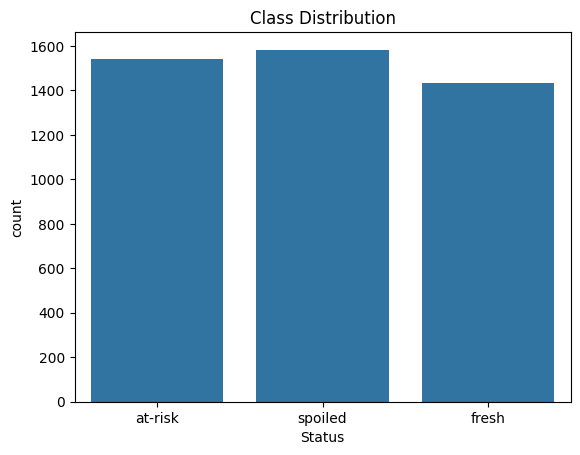

In [8]:
# Create a count plot to visualize the distribution of 'Status' (class distribution)
sns.countplot(x='Status', data=df)
# Set the title of the plot
plt.title("Class Distribution")
# Display the plot
plt.show()

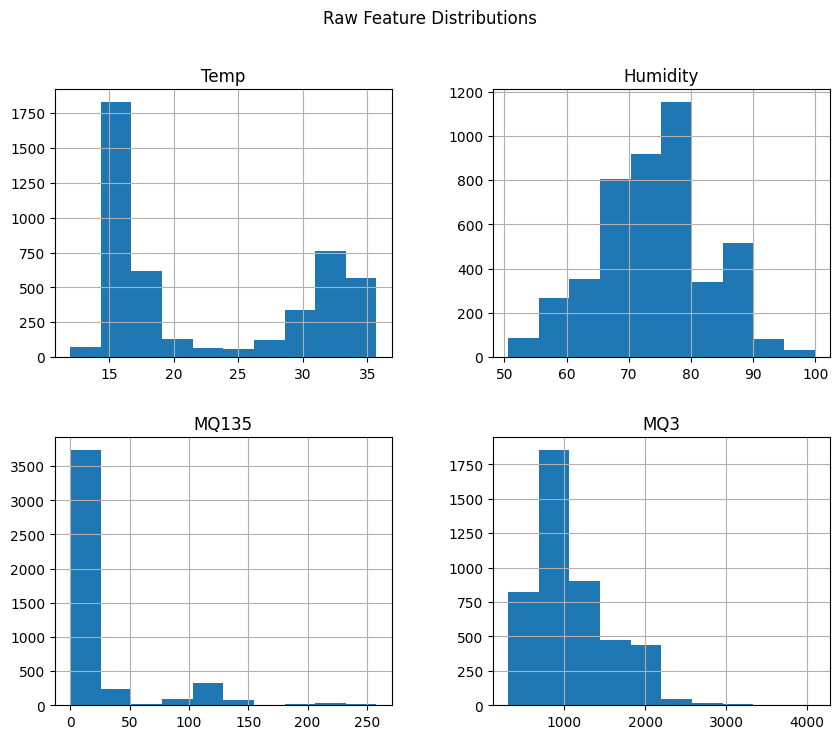

In [9]:
# Plot histograms for selected numerical features to observe their distributions
df[['Temp','Humidity','MQ135','MQ3']].hist(figsize=(10,8))
# Set a common title for all subplots (histograms)
plt.suptitle("Raw Feature Distributions")
# Display the plot
plt.show()

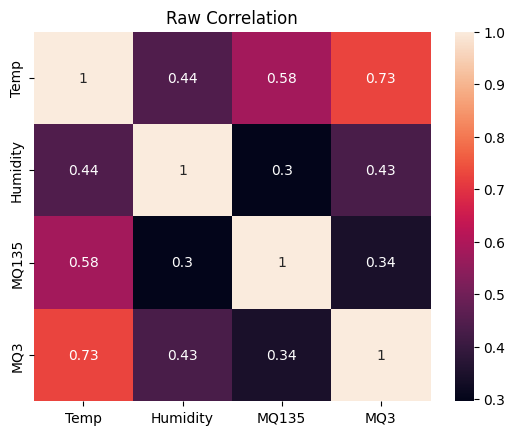

In [10]:
# Calculate the correlation matrix for selected numerical features
# and visualize it using a heatmap for 'Raw Correlation'
sns.heatmap(df[['Temp','Humidity','MQ135','MQ3']].corr(), annot=True)
# Set the title of the heatmap
plt.title("Raw Correlation")
# Display the plot
plt.show()

In [12]:
# Extract the hour of the day from the 'Time' column
df['hour'] = df['Time'].dt.hour
# Calculate elapsed minutes from the earliest timestamp in the 'Time' column
df['elapsed_min'] = (df['Time'] - df['Time'].min()).dt.total_seconds()/60

In [13]:
# Calculate the difference between consecutive MQ3 readings, filling the first NaN with 0
df['MQ3_diff'] = df['MQ3'].diff().fillna(0)
# Calculate the difference between consecutive MQ135 readings, filling the first NaN with 0
df['MQ135_diff'] = df['MQ135'].diff().fillna(0)

# Calculate a 3-period rolling mean for MQ3 readings, backfilling initial NaNs
df['MQ3_roll'] = df['MQ3'].rolling(3).mean().bfill()
# Calculate a 3-period rolling mean for MQ135 readings, backfilling initial NaNs
df['MQ135_roll'] = df['MQ135'].rolling(3).mean().bfill()

In [14]:
# Apply one-hot encoding to the 'Fruit' column, converting categorical text into numerical format
df = pd.get_dummies(df, columns=['Fruit'])

In [15]:
# Initialize LabelEncoder for converting categorical labels to numerical ones
le = LabelEncoder()
# Fit LabelEncoder to the 'Status' column and transform it to numerical labels
df['Status'] = le.fit_transform(df['Status'])

In [16]:
# Drop the original 'Time' column as time-based features have already been extracted
df = df.drop(columns=[ 'Time'])

## 3. Exploratory Data Analysis (EDA)

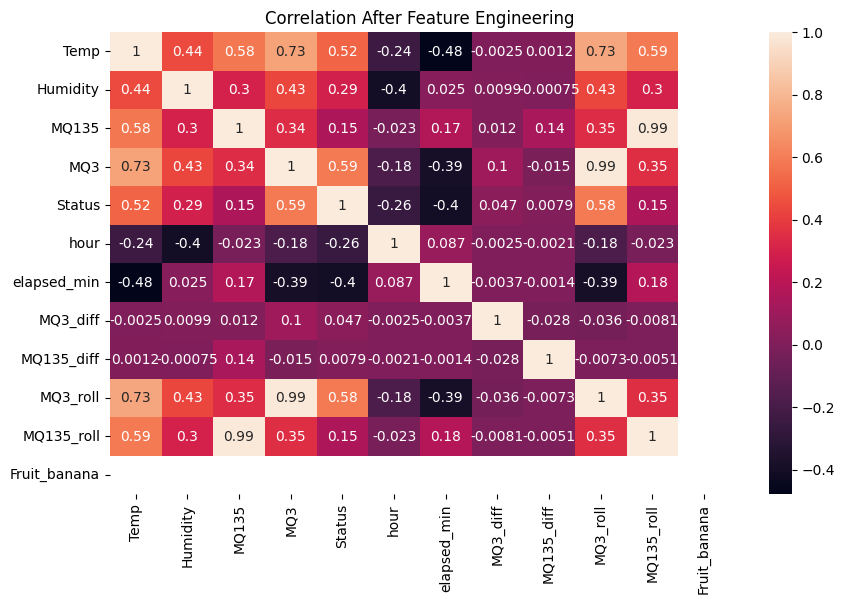

In [17]:
# Set the figure size for the heatmap
plt.figure(figsize=(10,6))
# Compute and plot the correlation matrix of the DataFrame after feature engineering
sns.heatmap(df.corr(), annot=True)
# Set the title of the heatmap
plt.title("Correlation After Feature Engineering")
# Display the plot
plt.show()

In [18]:
# Print the counts of each unique value in the 'Status' column
print(df['Status'].value_counts())

Status
2    1583
0    1541
1    1434
Name: count, dtype: int64


## 4. Model Preparation

In [19]:
# Define features (X) by dropping the 'Status' column
X = df.drop('Status', axis=1)
# Define target variable (y) as the 'Status' column
y = df['Status']

# Split the dataset into training and testing sets
# test_size=0.2 means 20% of data for testing, 80% for training
# random_state for reproducibility of the split
# stratify=y ensures that the proportion of target classes is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Impute Missing Values

Before applying SMOTE, we need to handle any remaining `NaN` values in `X_train` and `X_test`. These often arise from feature engineering steps, particularly when dealing with time-related features where original `NaT` values propagate. Using median imputation is a good approach for numerical features as it is less sensitive to outliers than mean imputation.

In [20]:
from sklearn.impute import SimpleImputer

# Identify numerical columns in X_train that contain NaN values
numerical_cols_with_nan = X_train.select_dtypes(include=np.number).columns[X_train.select_dtypes(include=np.number).isnull().any()].tolist()

# Dictionary to store median values for imputation, to be used consistently during prediction
median_imputation_values = {}
for col in numerical_cols_with_nan:
    median_val = X_train[col].median()
    median_imputation_values[col] = median_val
    # Fill NaN values in training set with the column's median
    X_train[col] = X_train[col].fillna(median_val)
    # Fill NaN values in testing set with the training set's median for consistency
    X_test[col] = X_test[col].fillna(median_val)


# Initialize StandardScaler for feature scaling (standardization)
scaler = StandardScaler()
# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames, retaining column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Verify that no NaN values remain after imputation
print("NaN values after imputation in X_train:", X_train.isnull().sum().sum())
print("NaN values after imputation in X_test:", X_test.isnull().sum().sum())

NaN values after imputation in X_train: 0
NaN values after imputation in X_test: 0


In [21]:
# Print the class distribution before applying SMOTE
print("Before SMOTE:", np.bincount(y_train))

# Initialize SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance
sm = SMOTE()
# Apply SMOTE to the training data to balance class distribution
X_train, y_train = sm.fit_resample(X_train, y_train)

# Print the class distribution after applying SMOTE
print("After SMOTE:", np.bincount(y_train))

Before SMOTE: [1233 1147 1266]
After SMOTE: [1266 1266 1266]


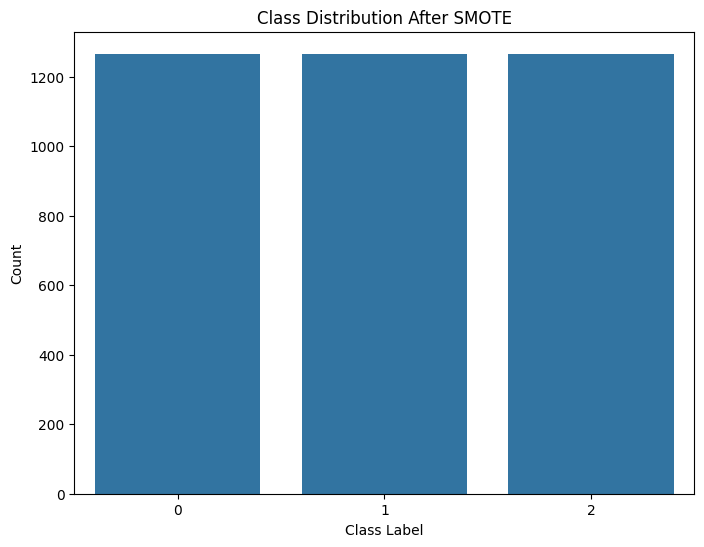

In [22]:
# Set the figure size for the plot
plt.figure(figsize=(8, 6))
# Create a count plot to visualize the class distribution after SMOTE
sns.countplot(x=y_train)
# Set the title of the plot
plt.title('Class Distribution After SMOTE')
# Set the x-axis label
plt.xlabel('Class Label')
# Set the y-axis label
plt.ylabel('Count')
# Display the plot
plt.show()

## 5. Model Training and Hyperparameter Tuning

In [23]:
# Initialize a RandomForestClassifier with 200 estimators and a fixed random state for reproducibility
rf = RandomForestClassifier(n_estimators=200, random_state=42)
# Train the Random Forest model on the balanced training data
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [24]:
# Initialize an XGBoost Classifier with 'mlogloss' as the evaluation metric for multiclass classification
xgb = XGBClassifier(eval_metric='mlogloss')
# Train the XGBoost model on the balanced training data
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)